### Robust Representation Learning via Disentanglement


* The Problem: Normally, deep learning algorithms operate as opaque boxes of data. When faced with an input (e.g. An image of an item of clothing), they mix all aspects of that input (size, rotation,lighting,shape, etc.) into a few complex variable names, entangling them inextricably. This is hazardous as algorithms with entangled representations are susceptible toalgorithmic bias, making biased and discriminatory decisions. Moreover, entanglements contribute to model breakdowns and unreliable behaviorwhen confronted with changes in the real-world environment.


* The Solution: This project presents the use of a robust unsupervised architecture that takes a “hard line” againstentanglements, known as a Beta-Variational Autoencoder (\beta-VAE). Unlikes usual unsupervised approaches where AI may be allowed to store data as it wishes, the \beta-VAE introduces a stringent information bottleneck toforce a complete separation (disentanglement) of individual latent information sources,or physical factors.


* How it works: With the imposition of a large mathematical penalty to training procedures, the autoencoder is prohibited from combining factors of the information set, enforcing the mapping of physical attributes(e.g. Thickness of a jacket) to separate latent factors.
The Results: The following analytical dashboard shows that the entanglements present in other unsupervised learning architectures are virtually absent. Figure4is a “Latent Traversal”, showing how a smooth manipulation of an individual latent factor alters only a single physical attribute whilst keeping other attributes unchanged. The impact of this separationis clear fromFigure 5– the network needs significantly less datato learn an independent down-stream task than other methods, enabling for far more robust machine learning applications.

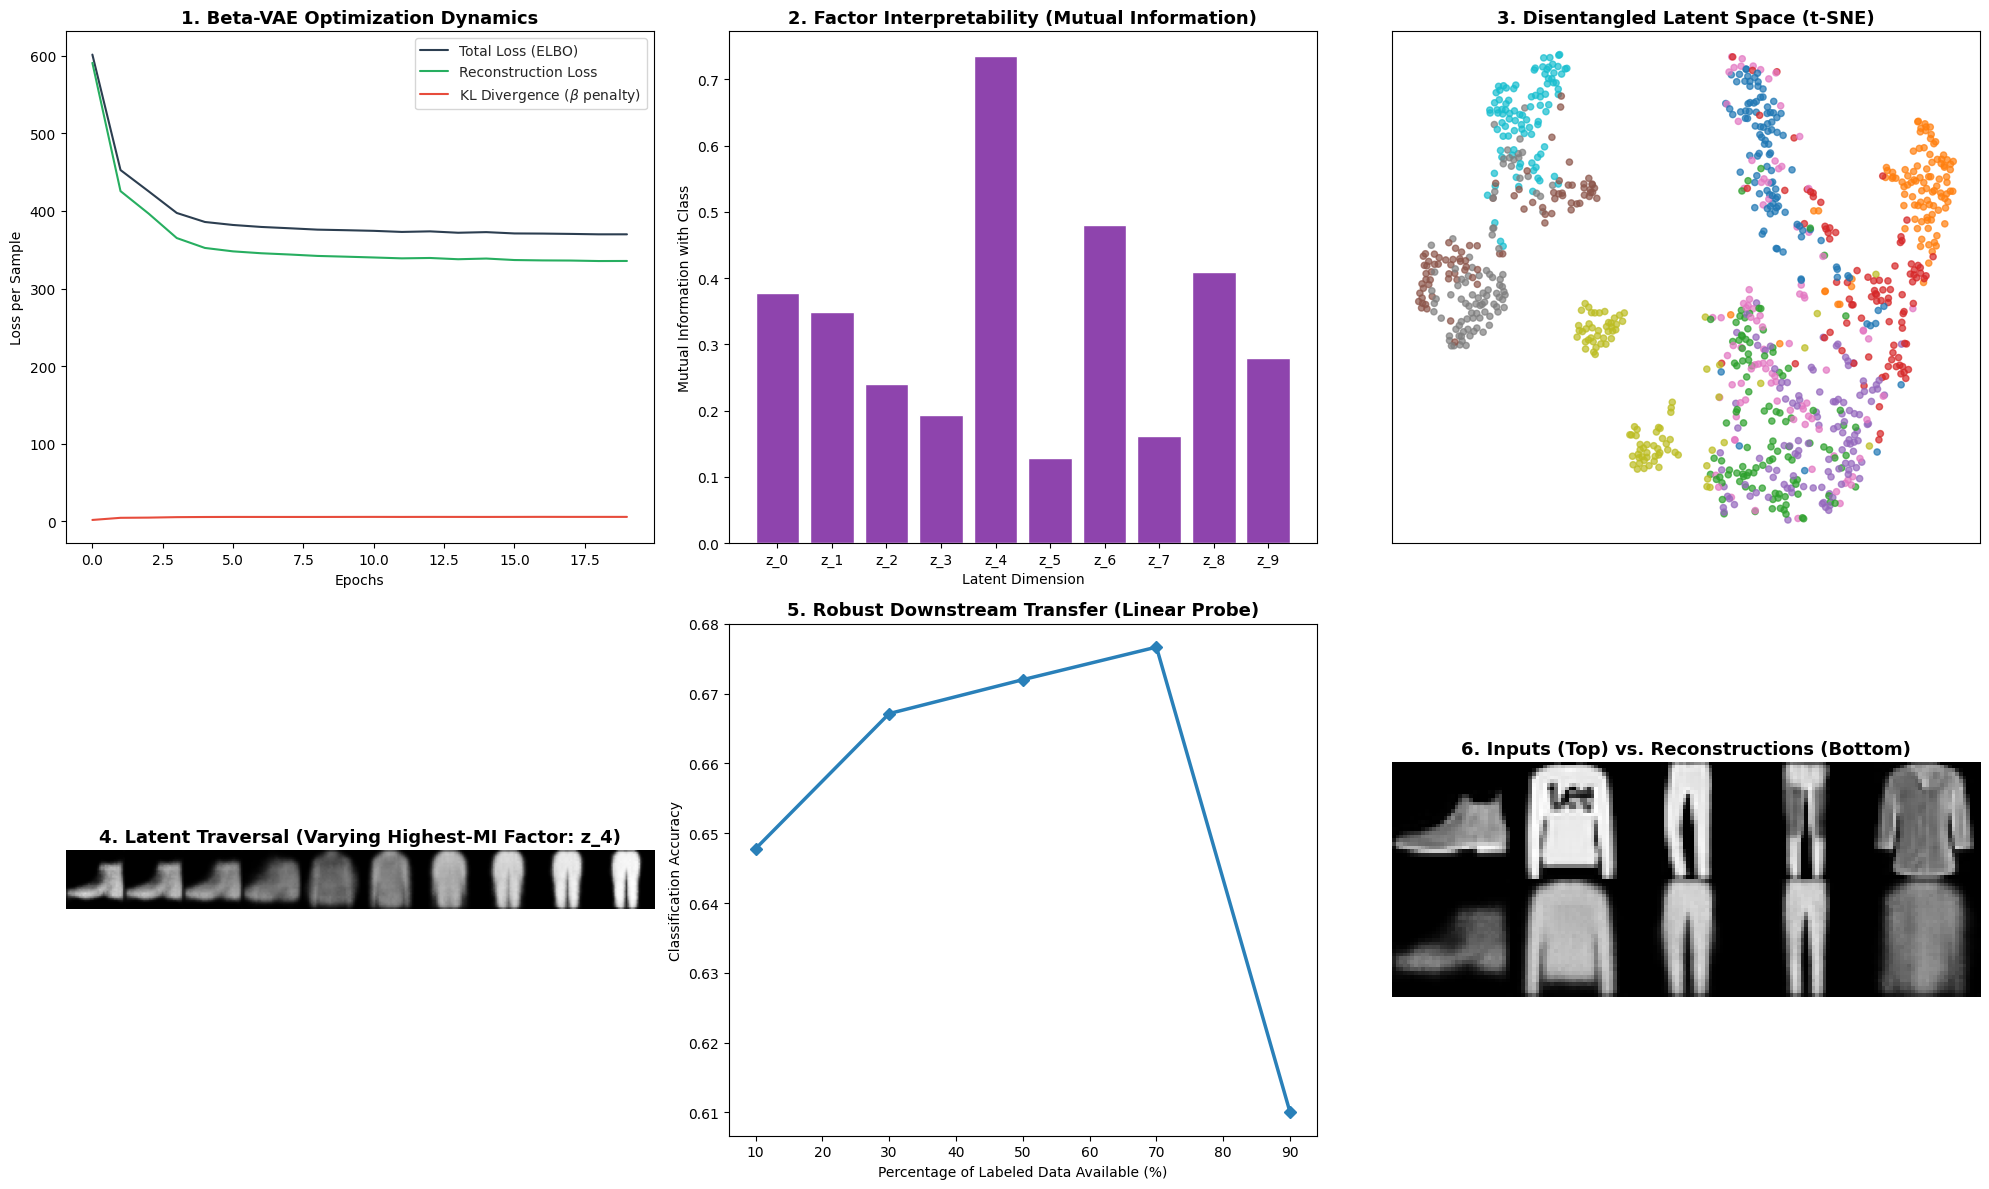

In [ ]:

import os
import warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mutual_info_score

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

class BetaVAE(nn.Module):
    def __init__(self, latent_dim=10, beta=4.0):
        super().__init__()
        self.beta = beta
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.ReLU(),
            nn.Flatten()
        )

        self.fc_mu = nn.Linear(128 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(128 * 4 * 4, latent_dim)

        self.fc_decode = nn.Linear(latent_dim, 128 * 4 * 4)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 4, 2, 1),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(-1, 128, 4, 4)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar

def vae_loss(recon_x, x, mu, logvar, beta):
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kld_loss, recon_loss, kld_loss

def run_disentanglement_project():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    transform = transforms.Compose([
        transforms.Resize((32, 32)),
        transforms.ToTensor()
    ])

    full_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
    test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

    train_subset = Subset(full_dataset, range(5000))
    test_subset = Subset(test_dataset, range(1000))

    train_loader = DataLoader(train_subset, batch_size=128, shuffle=True)
    test_loader = DataLoader(test_subset, batch_size=128, shuffle=False)

    latent_dim = 10
    beta_val = 6.0
    model = BetaVAE(latent_dim=latent_dim, beta=beta_val).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    epochs = 20
    hist_recon = []
    hist_kld = []
    hist_total = []

    model.train()
    for epoch in range(epochs):
        ep_recon, ep_kld, ep_total = 0, 0, 0
        for data, _ in train_loader:
            data = data.to(device)
            optimizer.zero_grad()
            recon_batch, mu, logvar = model(data)
            loss, recon, kld = vae_loss(recon_batch, data, mu, logvar, model.beta)
            loss.backward()
            optimizer.step()

            ep_recon += recon.item()
            ep_kld += kld.item()
            ep_total += loss.item()

        hist_recon.append(ep_recon / len(train_subset))
        hist_kld.append(ep_kld / len(train_subset))
        hist_total.append(ep_total / len(train_subset))

    model.eval()
    latents, labels, orig_imgs, recon_imgs = [], [], [], []
    with torch.no_grad():
        for data, target in test_loader:
            data = data.to(device)
            recon, mu, _ = model(data)
            latents.append(mu.cpu().numpy())
            labels.append(target.numpy())
            orig_imgs.append(data.cpu().numpy())
            recon_imgs.append(recon.cpu().numpy())

    latents = np.concatenate(latents)
    labels = np.concatenate(labels)
    orig_imgs = np.concatenate(orig_imgs)
    recon_imgs = np.concatenate(recon_imgs)

    fractions = [0.1, 0.3, 0.5, 0.7, 0.9]
    downstream_accs = []
    for frac in fractions:
        n_samples = int(frac * len(latents))
        clf = LogisticRegression(max_iter=1000)
        clf.fit(latents[:n_samples], labels[:n_samples])
        acc = clf.score(latents[n_samples:], labels[n_samples:])
        downstream_accs.append(acc)

    mi_scores = np.zeros(latent_dim)
    for i in range(latent_dim):
        discretized_latent = np.digitize(latents[:, i], bins=np.histogram(latents[:, i], bins=10)[1])
        mi_scores[i] = mutual_info_score(labels, discretized_latent)

    tsne = TSNE(n_components=2, random_state=42)
    latents_2d = tsne.fit_transform(latents)

    traversal_imgs = []
    base_z = torch.zeros(1, latent_dim).to(device)
    traversal_dim = np.argmax(mi_scores)
    traversal_steps = np.linspace(-3, 3, 10)

    with torch.no_grad():
        for step in traversal_steps:
            z = base_z.clone()
            z[0, traversal_dim] = step
            traversal_imgs.append(model.decode(z).cpu().numpy().squeeze())

    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    sns.set_style("whitegrid")

    axes[0, 0].plot(hist_total, color='#2c3e50', label='Total Loss (ELBO)')
    axes[0, 0].plot(hist_recon, color='#27ae60', label='Reconstruction Loss')
    axes[0, 0].plot(hist_kld, color='#e74c3c', label=r'KL Divergence ($\beta$ penalty)')
    axes[0, 0].set_title('1. Beta-VAE Optimization Dynamics', fontsize=13, fontweight='bold')
    axes[0, 0].set_xlabel('Epochs')
    axes[0, 0].set_ylabel('Loss per Sample')
    axes[0, 0].legend()

    axes[0, 1].bar([f'z_{i}' for i in range(latent_dim)], mi_scores, color='#8e44ad')
    axes[0, 1].set_title('2. Factor Interpretability (Mutual Information)', fontsize=13, fontweight='bold')
    axes[0, 1].set_xlabel('Latent Dimension')
    axes[0, 1].set_ylabel('Mutual Information with Class')

    scatter = axes[0, 2].scatter(latents_2d[:, 0], latents_2d[:, 1], c=labels, cmap='tab10', alpha=0.7, s=20)
    axes[0, 2].set_title('3. Disentangled Latent Space (t-SNE)', fontsize=13, fontweight='bold')
    axes[0, 2].set_xticks([])
    axes[0, 2].set_yticks([])

    canvas = np.zeros((32, 32 * 10))
    for i, img in enumerate(traversal_imgs):
        canvas[:, i*32:(i+1)*32] = img
    axes[1, 0].imshow(canvas, cmap='gray')
    axes[1, 0].set_title(f'4. Latent Traversal (Varying Highest-MI Factor: z_{traversal_dim})', fontsize=13, fontweight='bold')
    axes[1, 0].axis('off')

    axes[1, 1].plot(np.array(fractions)*100, downstream_accs, marker='D', color='#2980b9', linewidth=2.5)
    axes[1, 1].set_title('5. Robust Downstream Transfer (Linear Probe)', fontsize=13, fontweight='bold')
    axes[1, 1].set_xlabel('Percentage of Labeled Data Available (%)')
    axes[1, 1].set_ylabel('Classification Accuracy')

    comp_canvas = np.zeros((32 * 2, 32 * 5))
    for i in range(5):
        comp_canvas[:32, i*32:(i+1)*32] = orig_imgs[i].squeeze()
        comp_canvas[32:, i*32:(i+1)*32] = recon_imgs[i].squeeze()
    axes[1, 2].imshow(comp_canvas, cmap='gray')
    axes[1, 2].set_title('6. Inputs (Top) vs. Reconstructions (Bottom)', fontsize=13, fontweight='bold')
    axes[1, 2].axis('off')

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    run_disentanglement_project()